# 🎬 Netflix Data — Relative Frequency, Cumulative Frequency & Quartile Range
### A Step-by-Step Guide Using Real Netflix Data
**Dataset:** netflix_titles.csv &nbsp;|&nbsp; **Tools:** Python, Pandas, Matplotlib

---
> **What we are learning today:**
> We already know how to count how many times something appears. Today we go three steps further:
>
> | Concept | Simple Definition |
> |---|---|
> | **Relative Frequency** | Turning raw counts into *percentages* so we can compare fairly |
> | **Cumulative Frequency** | Keeping a *running total* so we can answer "how many up to this point?" |
> | **Quartile Range (IQR)** | Measuring the *spread of the middle 50%* of data — ignoring extremes |
>
> We will use the `release_year` column — the year each Netflix movie was originally made.
> This is different from duration. Instead of asking *"how long is a movie?"* we ask *"when was it made?"*


---
## 📦 Step 1 — Import Libraries & Load the Data

In [1]:
# We always start by importing the tools we need
# pandas  → for loading and working with data tables
# matplotlib → for drawing charts

import pandas as pd
import matplotlib.pyplot as plt

# Load the Netflix CSV file into a DataFrame called df
# Make sure netflix_titles.csv is in the same folder as this notebook
df = pd.read_csv("netflix_titles.csv")

print("Dataset loaded successfully!")
print(f"Total rows : {df.shape[0]}")
print(f"Total columns : {df.shape[1]}")


Dataset loaded successfully!
Total rows : 6234
Total columns : 12


### 🎯 Filter to Movies Only
We only want Movies — not TV Shows — so we filter the DataFrame first.

In [2]:
# Filter the dataset so we only keep rows where the 'type' column says 'Movie'
# df[df['type'] == 'Movie'] means: give me only the rows where type equals Movie
movies = df[df['type'] == 'Movie'].copy()

print(f"Total movies found: {len(movies)}")


Total movies found: 4265


---
## 🔍 Step 2 — Checking and Handling Missing Values

Before we calculate anything, we must check whether any values are missing (NaN).

> 💡 **What is NaN?**
> NaN stands for **Not a Number**. It means the data is missing — the cell is empty.
> If we try to calculate statistics (like the mean) with NaN values in the column,
> Python will either give us a wrong answer or an error.
> We must always deal with missing values **before** doing any analysis.


In [3]:
# Check how many values are missing in the release_year column
# isnull() returns True for every missing value
# .sum() counts how many Trues there are

missing_count = movies['release_year'].isnull().sum()
print(f"Missing values in release_year: {missing_count}")


Missing values in release_year: 0


> 💡 **Why do we replace NaN with the mean?**
> We have two common choices when a value is missing:
>
> | Option | What it does | When to use it |
> |---|---|---|
> | **Drop the row** | Deletes any row with a missing value | When very few rows are missing |
> | **Fill with the mean** | Replaces NaN with the average value | When we want to keep all rows and the mean is a fair estimate |
>
> For `release_year`, replacing with the **mean year** is sensible — it says
> *"we don't know exactly when this was released, so we assume it is around the average year."*
> This is called **mean imputation**.


In [4]:
# Step 1: Calculate the mean of release_year BEFORE filling
# We use round() to get a whole year number (you can't have a year like 2015.7)
mean_year = round(movies['release_year'].mean())

print(f"Mean release year (used to fill NaN): {mean_year}")

# Step 2: Fill any missing values with the mean year we just calculated
# fillna() replaces every NaN with the value we give it
# inplace=True means we update the column directly — no need to reassign
movies['release_year'].fillna(mean_year, inplace=True)

# Step 3: Confirm there are no more missing values
print(f"Missing values after filling: {movies['release_year'].isnull().sum()}")
print("All missing values have been replaced with the mean year.")


Mean release year (used to fill NaN): 2012
Missing values after filling: 0
All missing values have been replaced with the mean year.


C:\Users\HP\AppData\Local\Temp\ipykernel_13776\2214306032.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movies['release_year'].fillna(mean_year, inplace=True)


> 💡 **Checking your work:**
> After filling missing values, always run `.isnull().sum()` again to confirm the count is now **0**.
> This is a good habit — never assume the fill worked without verifying it.


---
## 📊 Step 3 — What is Relative Frequency?

### The Problem with Raw Counts

Imagine two cinemas:
- Cinema A showed **50 comedies** out of 100 films total
- Cinema B showed **50 comedies** out of 200 films total

Both showed 50 comedies — but Cinema A shows **proportionally more** comedy.
Raw frequency (50 vs 50) hides this. **Relative frequency** fixes this by converting counts to percentages.

---

### Definition

$$\text{Relative Frequency (\%)} = \frac{\text{Frequency}}{\text{Total}} \times 100$$

- **Frequency** = how many times a value appears
- **Total** = the total number of values in the dataset
- **Relative Frequency** = what *percentage* of the total this represents

---

### Example from Netflix

If 800 movies were released between 2015 and 2018, and there are 4000 movies total:

$$\text{Relative Frequency} = \frac{800}{4000} \times 100 = 20\%$$

This tells us: *20% of all Netflix movies were released between 2015 and 2018.*


In [5]:
# First, let's filter to years 2000 onwards (very old titles are rare)
movies = movies[movies['release_year'] >= 2000]

# pd.cut() divides the release_year values into class intervals (bins)
# bins=range(2000, 2022, 3) creates intervals: 2000-2003, 2003-2006, ... 2018-2021
# Each interval has a width of 3 years
bins = range(2000, 2022, 3)

# Count how many movies fall into each interval
# sort_index() ensures the intervals are shown in chronological order
freq = pd.cut(movies['release_year'], bins=bins).value_counts().sort_index()

# Calculate the total number of movies across all intervals
total = freq.values.sum()

# Calculate relative frequency for each interval
# Divide each frequency by the total and multiply by 100 to get a percentage
# .round(2) keeps only 2 decimal places
relative_freq = (freq.values / total * 100).round(2)

print("Raw Frequency and Relative Frequency:")
print()
for interval, f, r in zip(freq.index, freq.values, relative_freq):
    print(f"  {str(interval):20s}  |  Frequency: {f:4d}  |  Relative Freq: {r:5.2f}%")
print(f"{'':20s}  |  Total:     {total:4d}  |  Total:          100.00%")


Raw Frequency and Relative Frequency:

  (2000, 2003]          |  Frequency:  100  |  Relative Freq:  2.56%
  (2003, 2006]          |  Frequency:  150  |  Relative Freq:  3.85%
  (2006, 2009]          |  Frequency:  234  |  Relative Freq:  6.00%
  (2009, 2012]          |  Frequency:  336  |  Relative Freq:  8.62%
  (2012, 2015]          |  Frequency:  753  |  Relative Freq: 19.31%
  (2015, 2018]          |  Frequency: 1921  |  Relative Freq: 49.26%
  (2018, 2021]          |  Frequency:  406  |  Relative Freq: 10.41%
                      |  Total:     3900  |  Total:          100.00%


> 💡 **Key points about Relative Frequency:**
> - The relative frequencies of all class intervals must **always add up to 100%**
> - It allows fair comparison even when datasets have different sizes
> - It answers the question: *"What share of the total does this group represent?"*


---
## 📈 Step 4 — What is Cumulative Frequency?

### The Idea

**Cumulative** means *adding up as you go* — like a running total.

Think of a football match scoreboard:
- After 10 mins: Team A scores 1 goal → **total so far: 1**
- After 30 mins: Team A scores 2 more → **total so far: 3**
- After 70 mins: Team A scores 1 more → **total so far: 4**

Each entry **adds to everything before it**. That is cumulative frequency.

---

### Definition

$$\text{Cumulative Frequency} = \text{Sum of all frequencies UP TO and INCLUDING this class interval}$$

$$\text{Cumulative Relative Frequency (\%)} = \frac{\text{Cumulative Frequency}}{\text{Total}} \times 100$$

---

### Example from Netflix

| Class Interval | Frequency | Cumulative Frequency | Cumulative Rel (%) |
|---|---|---|---|
| 2000–2003 | 50 | 50 | 1.2% |
| 2003–2006 | 80 | 130 | 3.1% |
| 2006–2009 | 120 | 250 | 5.9% |
| … | … | … | … |

The cumulative frequency for **2003–2006** is 50 + 80 = **130**.
This answers: *"How many Netflix movies were released up to 2006?"*

The last row of cumulative frequency always equals the **total** (and cumulative rel % = **100%**).


In [6]:
# .cumsum() is the pandas function for cumulative sum
# It adds up values one by one from the top of the column downwards
# For example: [10, 20, 30] becomes [10, 30, 60]

cumulative_freq     = freq.values.cumsum()
cumulative_rel_freq = (cumulative_freq / total * 100).round(2)

# Now build the complete formal frequency table combining all four columns
freq_table = pd.DataFrame({
    'Class Interval':     freq.index.astype(str),   # the year range labels
    'Frequency':          freq.values,               # raw count per interval
    'Relative Freq (%)':  relative_freq,             # percentage of total
    'Cumulative Freq':    cumulative_freq,            # running total of frequency
    'Cumulative Rel (%)': cumulative_rel_freq         # running total as percentage
})

# Print the table with a clear header and footer
print("=" * 78)
print("       FORMAL FREQUENCY TABLE — Netflix Movie Release Years")
print("=" * 78)
print(freq_table.to_string(index=False))
print("=" * 78)
print(f"  TOTAL     {total}        100.00%")
print("=" * 78)


       FORMAL FREQUENCY TABLE — Netflix Movie Release Years
Class Interval  Frequency  Relative Freq (%)  Cumulative Freq  Cumulative Rel (%)
  (2000, 2003]        100               2.56              100                2.56
  (2003, 2006]        150               3.85              250                6.41
  (2006, 2009]        234               6.00              484               12.41
  (2009, 2012]        336               8.62              820               21.03
  (2012, 2015]        753              19.31             1573               40.33
  (2015, 2018]       1921              49.26             3494               89.59
  (2018, 2021]        406              10.41             3900              100.00
  TOTAL     3900        100.00%


> 💡 **How to read this table — four questions it answers:**
>
> | Column | Question it answers |
> |---|---|
> | **Frequency** | How many movies were released *in this period*? |
> | **Relative Freq (%)** | What *percentage* of all movies came from this period? |
> | **Cumulative Freq** | How many movies were released *up to and including* this period? |
> | **Cumulative Rel (%)** | What *percentage* of all movies were released up to this period? |
>
> **Quick check:** The last row of *Cumulative Rel (%)* must always be **100%**.
> If it is not, something is wrong with your calculation.


---
## 📐 Step 5 — What is the Quartile Range (IQR)?

### The Problem with Standard Deviation

Standard deviation tells us how spread out *all* values are from the mean.
But it is strongly affected by extreme values (outliers).

For example — if one very old movie from 1920 is in the dataset, it pulls the mean back
and makes the standard deviation much larger, even though most movies are modern.

The **Interquartile Range (IQR)** solves this by measuring only the *middle 50%* of the data —
completely ignoring the top 25% and bottom 25%.

---

### What are Quartiles?

Quartiles split the dataset into **four equal parts** — like cutting a cake into 4 equal slices.

```
|-------- 25% --------|-------- 25% --------|-------- 25% --------|-------- 25% --------|
↑                     ↑                     ↑                     ↑                     ↑
Minimum              Q1                    Q2                    Q3                  Maximum
                 (25th pct)           (50th pct)            (75th pct)
                                     = Median
```

| Quartile | What it means | Percentile |
|---|---|---|
| **Q1** | 25% of movies were released *before* this year | 25th |
| **Q2** | 50% of movies were released *before* this year — this **is** the median | 50th |
| **Q3** | 75% of movies were released *before* this year | 75th |
| **IQR** | The range covering the *middle 50%* of release years = **Q3 − Q1** | — |

---

### Why IQR is useful

$$\text{IQR} = Q3 - Q1$$

- A **small IQR** → most movies were released within a *narrow* time window → data is concentrated
- A **large IQR** → release years are spread across a *wide* range → more varied content

The IQR is resistant to outliers because it always ignores the bottom 25% and top 25% of values.


In [7]:
# .quantile() calculates the value at a given percentile
# 0.25 = 25th percentile = Q1
# 0.50 = 50th percentile = Q2 (this is exactly the same as the median)
# 0.75 = 75th percentile = Q3

Q1  = movies['release_year'].quantile(0.25)
Q2  = movies['release_year'].quantile(0.50)   # same as .median()
Q3  = movies['release_year'].quantile(0.75)

# IQR = distance between Q1 and Q3
# This covers the middle 50% of all release years
IQR = Q3 - Q1

print("=" * 45)
print("   QUARTILE SUMMARY — Movie Release Years")
print("=" * 45)
print(f"  Q1  (25th percentile) : {Q1:.0f}")
print(f"  Q2  (Median / 50th)   : {Q2:.0f}")
print(f"  Q3  (75th percentile) : {Q3:.0f}")
print(f"  IQR (Q3 - Q1)         : {IQR:.0f} years")
print("=" * 45)


   QUARTILE SUMMARY — Movie Release Years
  Q1  (25th percentile) : 2013
  Q2  (Median / 50th)   : 2016
  Q3  (75th percentile) : 2018
  IQR (Q3 - Q1)         : 5 years


In [8]:
# Let's also look at ALL summary statistics together for comparison
# This helps us see how IQR relates to mean, median and standard deviation

mean_year = movies['release_year'].mean()
std_year  = movies['release_year'].std()

print("=" * 45)
print("   FULL SUMMARY — Movie Release Years")
print("=" * 45)
print(f"  Mean               : {mean_year:.1f}")
print(f"  Median (Q2)        : {Q2:.0f}")
print(f"  Standard Deviation : {std_year:.1f} years")
print(f"  Q1                 : {Q1:.0f}")
print(f"  Q3                 : {Q3:.0f}")
print(f"  IQR                : {IQR:.0f} years")
print(f"  Min release year   : {movies['release_year'].min():.0f}")
print(f"  Max release year   : {movies['release_year'].max():.0f}")
print(f"  Range (Max-Min)    : {movies['release_year'].max() - movies['release_year'].min():.0f} years")
print("=" * 45)


   FULL SUMMARY — Movie Release Years
  Mean               : 2014.7
  Median (Q2)        : 2016
  Standard Deviation : 4.2 years
  Q1                 : 2013
  Q3                 : 2018
  IQR                : 5 years
  Min release year   : 2000
  Max release year   : 2020
  Range (Max-Min)    : 20 years


> 💡 **IQR vs Standard Deviation — what is the difference?**
>
> | Measure | Includes outliers? | Based on | Best used when… |
> |---|---|---|---|
> | **Standard Deviation** | Yes — all values | Mean | Data is roughly symmetric with no extreme outliers |
> | **IQR** | No — ignores top & bottom 25% | Quartiles | Data is skewed or has outliers |
>
> For Netflix release years, most content is recent but a few very old movies exist.
> The IQR will give us a more reliable picture of where *most* content sits.


---
## 📊 Step 6 — Histogram: Seeing the Distribution

Before we draw the cumulative frequency curve, let's first look at the basic shape using a histogram.

> 💡 **Reminder — what a histogram shows:**
> Each bar represents a class interval. The height of the bar tells you how many movies fall in that range.
> A tall bar = many movies released in that period. A short bar = very few.


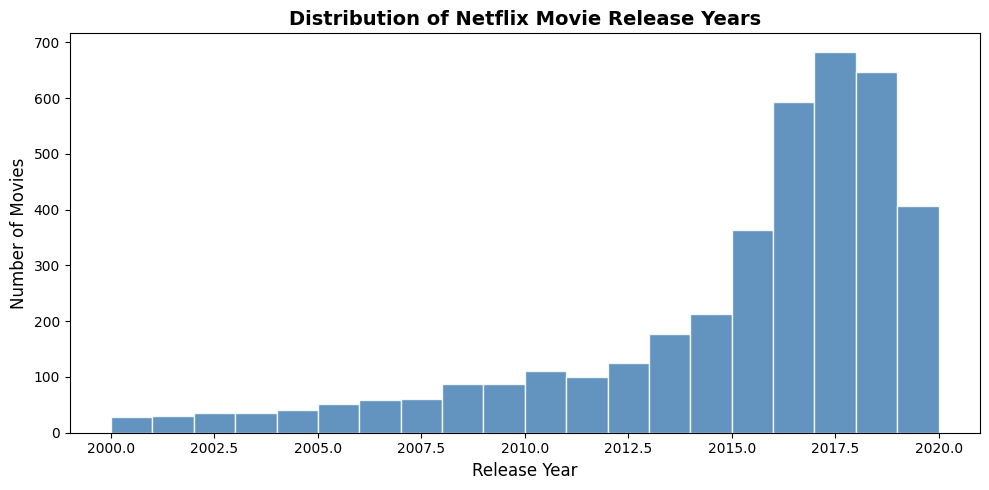

In [9]:
# Draw a simple histogram of release years
# bins=20 means we divide the data into 20 equal-width bars
# color sets the bar colour; edgecolor='white' draws a thin white line between bars

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(movies['release_year'],
        bins=20,
        color='steelblue',
        edgecolor='white',
        alpha=0.85)

# Add a title and axis labels so the chart is clearly described
ax.set_title('Distribution of Netflix Movie Release Years', fontsize=14, fontweight='bold')
ax.set_xlabel('Release Year', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)

plt.tight_layout()
plt.show()


> 💡 **What to look for in this histogram:**
> - **Where is the tallest bar?** This is the modal class — the most common release year range
> - **Is the distribution symmetric** (same shape on both sides) **or skewed** (leans left or right)?
> - **Are there very short bars on the left?** This tells you that very few old movies are on Netflix
>
> A distribution that **leans right with a long tail on the left** is called **negatively skewed** (left-skewed).
> A distribution that **leans left with a long tail on the right** is called **positively skewed** (right-skewed).


---
### ❓ Questions on the Histogram

**Q12.** Describe the shape of the histogram in 1–2 sentences.
Is it symmetric, or does it lean heavily to one side?
> Your answer: _______________________________________________

**Q13.** Most Netflix movies in the dataset were released in which rough time period?
Why do you think Netflix has more recently released movies than older ones?
> Your answer: _______________________________________________


---
## 📈 Step 7 — The Ogive (Cumulative Frequency Curve)

### What is an Ogive?

An **ogive** (pronounced *oh-jive*) is a **line chart of cumulative relative frequency**.

It answers: *"What percentage of movies were released UP TO this year?"*

### Properties of an Ogive

- It **always rises** from left to right — because cumulative totals can only increase
- It **always starts near 0%** and **ends at exactly 100%**
- A **steep section** means many values fall in that range — the data is concentrated there
- A **flat section** means very few values — that range is rare in the dataset

### Reading Quartiles from the Ogive

This is the most powerful use of an ogive. We draw three horizontal lines:

| Line | Percentage | What we read off |
|---|---|---|
| Green dashed | 25% | Where it hits the curve → **Q1** |
| Orange dashed | 50% | Where it hits the curve → **Q2 (Median)** |
| Red dashed | 75% | Where it hits the curve → **Q3** |

The IQR is the horizontal distance between the green line and the red line.


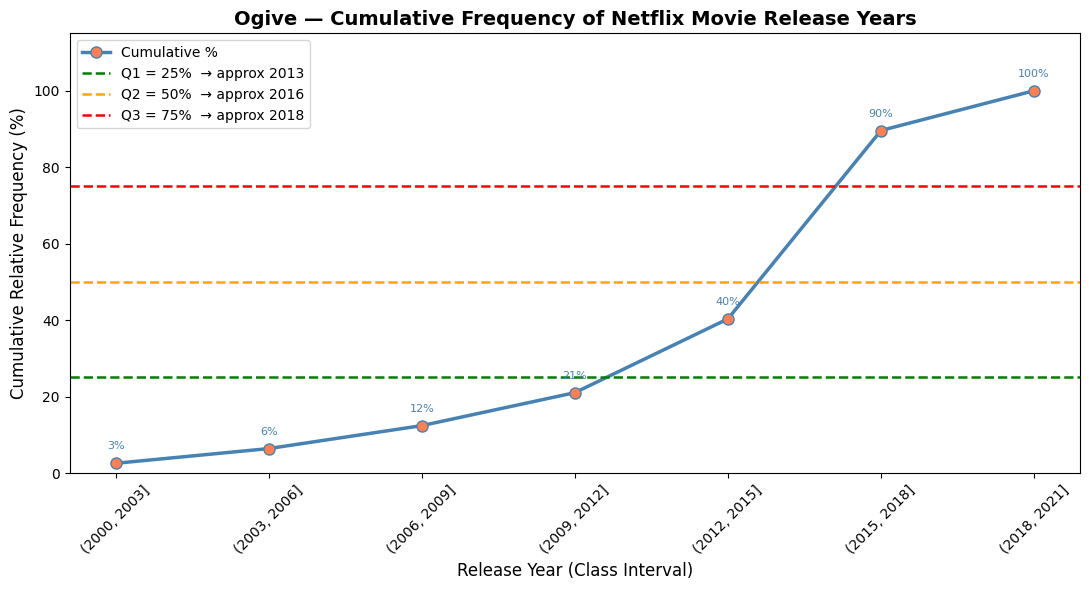

In [10]:
# Draw the Ogive — a line chart of cumulative relative frequency
fig, ax = plt.subplots(figsize=(11, 6))

# Plot the cumulative relative frequency as a line with circle markers
# marker='o' adds a dot at each data point
# markerfacecolor='coral' makes the inside of each dot coral coloured
ax.plot(freq_table['Class Interval'],      # x-axis: class intervals (year ranges)
        freq_table['Cumulative Rel (%)'],  # y-axis: cumulative percentage
        marker='o',
        color='steelblue',
        linewidth=2.5,
        markersize=8,
        markerfacecolor='coral',
        label='Cumulative %')

# Add three horizontal reference lines for Q1 (25%), Q2 (50%), Q3 (75%)
# axhline draws a horizontal line across the full width of the chart
ax.axhline(25, color='green',  linestyle='--', linewidth=1.8,
           label=f'Q1 = 25%  → approx {Q1:.0f}')
ax.axhline(50, color='orange', linestyle='--', linewidth=1.8,
           label=f'Q2 = 50%  → approx {Q2:.0f}')
ax.axhline(75, color='red',    linestyle='--', linewidth=1.8,
           label=f'Q3 = 75%  → approx {Q3:.0f}')

# Add the cumulative percentage value as a label above each point on the curve
for i, row in freq_table.iterrows():
    ax.annotate(
        f"{row['Cumulative Rel (%)']:.0f}%",   # the text to display
        xy=(i, row['Cumulative Rel (%)']),       # position of the data point
        xytext=(0, 10),                          # move the label 10 pixels upward
        textcoords='offset points',
        ha='center',
        fontsize=8,
        color='steelblue'
    )

# Titles and labels
ax.set_title('Ogive — Cumulative Frequency of Netflix Movie Release Years',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Release Year (Class Interval)', fontsize=12)
ax.set_ylabel('Cumulative Relative Frequency (%)', fontsize=12)
ax.set_ylim(0, 115)   # go slightly above 100 so the top labels have space
ax.legend(fontsize=10, loc='upper left')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


> 💡 **How to read the Ogive — step by step:**
>
> **To find Q2 (the median) from the chart:**
> 1. Find **50%** on the y-axis (left side)
> 2. Draw a horizontal line across until it **hits the curve**
> 3. Drop straight **down** to the x-axis
> 4. Read off the class interval — that is approximately where Q2 falls
>
> **What the shape tells you:**
> - A **steep rise** between two class intervals = many movies released in that period
> - A **flat section** = very few movies released in that period
> - The **IQR** is the horizontal gap between where the 25% line and 75% line cross the curve


---
## 🏋️ Step 8 — Your Turn! Student Challenges

Try these challenges on your own using what you have learned above.


### 🟡 Challenge 1 (Easy)
Print the exact Q1, Q2 and Q3 release years.
Then write **one sentence** for each quartile explaining what it means for a Netflix viewer
— do not just state the number, explain it in context.


In [ ]:
# Your code here


### 🟠 Challenge 2 (Medium)
Repeat the cumulative frequency table and ogive but this time use **only TV Shows**.

- Filter the original `df` for TV Shows
- Check for missing values in `release_year` and fill with the mean (as we did in Step 2)
- Build the frequency table and draw the ogive

Compare the Q2 (median release year) of TV Shows vs Movies.
Which tends to be newer content on Netflix?


In [ ]:
# Your code here


### 🔴 Challenge 3 (Hard)
The **IQR outlier rule** says:
- Any value **below Q1 − 1.5 × IQR** is a lower outlier
- Any value **above Q3 + 1.5 × IQR** is an upper outlier

Calculate the lower and upper fences for `release_year`.
Find any Netflix movies released before the lower fence.
Print their titles. What do these movies have in common?


In [ ]:
# Hint to get you started:
# lower_fence = Q1 - 1.5 * IQR
# upper_fence = Q3 + 1.5 * IQR
# outliers = movies[(movies['release_year'] < lower_fence) | (movies['release_year'] > upper_fence)]

# Your code here


---
## 📋 Quick Reference Cheatsheet

| What you want | Pandas / Matplotlib code |
|---|---|
| Check missing values | `df['col'].isnull().sum()` |
| Fill NaN with mean | `df['col'].fillna(df['col'].mean(), inplace=True)` |
| Group data into class intervals | `pd.cut(df['col'], bins=range(start, end, width))` |
| Count per interval | `.value_counts().sort_index()` |
| Relative frequency (%) | `(freq / total * 100).round(2)` |
| Cumulative frequency | `freq.cumsum()` |
| Q1 (25th percentile) | `df['col'].quantile(0.25)` |
| Q2 / Median (50th) | `df['col'].quantile(0.50)` |
| Q3 (75th percentile) | `df['col'].quantile(0.75)` |
| IQR | `Q3 - Q1` |
| Draw the ogive | `ax.plot(x, cumulative_values, marker='o')` |
| Add horizontal reference line | `ax.axhline(50, linestyle='--', color='orange')` |
| Add label above a point | `ax.annotate("text", xy=(x,y), xytext=(0,10), textcoords='offset points')` |
| Rotate x-axis labels | `ax.tick_params(axis='x', rotation=45)` |

---
*Happy analysing!* 🎬📊
